In [10]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to C:\Users\Nossim
[nltk_data]     Sankaire\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
# Path to dataset
data_path = "../data/train_raw.csv"

# Load CSV
df = pd.read_csv(data_path)

print("Dataset loaded:", df.shape)
df.head()


Dataset loaded: (400, 12)


,Master_Index,County,Health level,Years of Experience,Prompt,Nursing Competency,Clinical Panel,Clinician,GPT4.0,LLAMA,GEMINI,DDX SNOMED
0,ID_VBWWP,Uasin Gishu,Sub-county Hospitals and Nursing Homes,18.0,I am a nurse with 18 years of experience in Ge...,Pediatric Emergency Burns,SURGERY,Summary:\nA 4 year old with 5% superficial bur...,Given your vast experience as a nurse in Uasin...,1. Immediate treatment protocol for second-deg...,Here's a response addressing the questions reg...,288514009 | Burn involving 5 percent of body s...
1,ID_XMBBY,Uasin Gishu,National Referral Hospitals,17.0,I am a nurse with 17 years of experience in Ge...,Child Health,PAEDIATRICS,Summary\n6-year-old present with vomiting and ...,Clinical Summary: • A 6-year-old girl w...,Based on the symptoms and signs you've describ...,"Based on the presentation, the 6-year-old girl...",420270002 | Ketoacidosis due to type 1 diabete...
2,ID_JZNZW,Kiambu,Sub-county Hospitals and Nursing Homes,12.0,I am a nurse with 12 years of experience in Ge...,General Emergency,INTERNAL MEDICINE,Summary\nA 47-year-old man presents with sever...,"In this case, you're dealing with a 47-year-ol...","Firstly, I must commend you on your thorough h...","This 47-year-old male presenting with severe, ...",13200003 | Peptic ulcer (disorder)\n25458004 |...
3,ID_QOQTK,Uasin Gishu,National Referral Hospitals,12.0,I am a nurse with 12 years of experience in Pr...,Critical Care,INTERNAL MEDICINE,SUMMARY\n\n72-year-old female with inability t...,"Given ER's clinical presentation and vitals, t...",to me with this query. Based on the informatio...,This 92-year-old female patient (ER) presents ...,14760008 | Constipation (finding)\n419284004 |...
4,ID_ZFJBM,Uasin Gishu,National Referral Hospitals,16.0,I am a nurse with 16 years of experience in Ge...,Adult Health,INTERNAL MEDICINE,"A 22 year old female presents with headache, d...",The 22-year-old female patient is presenting w...,Thank you for presenting this case. Based on t...,This 22-year-old female patient presents with ...,95874006 | Carbon monoxide poisoning from fire...


In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).replace("_x0001_", " ")   
    text = re.sub(r"\s+", " ", text)           
    return text.strip()

df["Prompt_clean"] = df["Prompt"].apply(clean_text)

df[["Prompt", "Prompt_clean"]].head(5)


,Prompt,Prompt_clean
0,I am a nurse with 18 years of experience in Ge...,I am a nurse with 18 years of experience in Ge...
1,I am a nurse with 17 years of experience in Ge...,I am a nurse with 17 years of experience in Ge...
2,I am a nurse with 12 years of experience in Ge...,I am a nurse with 12 years of experience in Ge...
3,I am a nurse with 12 years of experience in Pr...,I am a nurse with 12 years of experience in Pr...
4,I am a nurse with 16 years of experience in Ge...,I am a nurse with 16 years of experience in Ge...


In [20]:
def segment_case(text):
    if pd.isna(text):
        return pd.Series(["", "", ""])
    
    text = str(text).strip()

    # Default
    symptoms, diagnosis, plan = text, "", ""

    # Step 1: Split narrative vs questions
    if "questions" in text.lower():
        parts = re.split(r"questions[:\-]?", text, flags=re.IGNORECASE, maxsplit=1)
        symptoms = parts[0].strip()
        if len(parts) > 1:
            questions = parts[1].strip()
        else:
            questions = ""
    else:
        if "?" in text:
            parts = text.split("?", 1)
            symptoms = parts[0] + "?"
            questions = parts[1]
        else:
            questions = ""

    # Step 2: Classify questions into diagnosis vs plan
    diagnosis_q, plan_q = [], []
    for q in questions.split("?"):
        q = q.strip()
        if q == "":
            continue
        if any(kw in q.lower() for kw in ["diagnosis", "cause", "confirm", "what could this be"]):
            diagnosis_q.append(q)
        elif any(kw in q.lower() for kw in ["management", "treatment", "care", "plan", "action", "protocol", "investigation", "what should i do"]):
            plan_q.append(q)
        else:
            # Default to plan if uncertain
            plan_q.append(q)

    diagnosis = " | ".join(diagnosis_q)
    plan = " | ".join(plan_q)

    return pd.Series([symptoms, diagnosis, plan])

# Apply segmentation
df[["Symptoms", "Diagnosis_Qs", "Plan_Qs"]] = df["Prompt_clean"].apply(segment_case)

# Preview sample
df[["Prompt_clean", "Symptoms", "Diagnosis_Qs", "Plan_Qs"]].head(10)


KeyError: 'Prompt_clean'

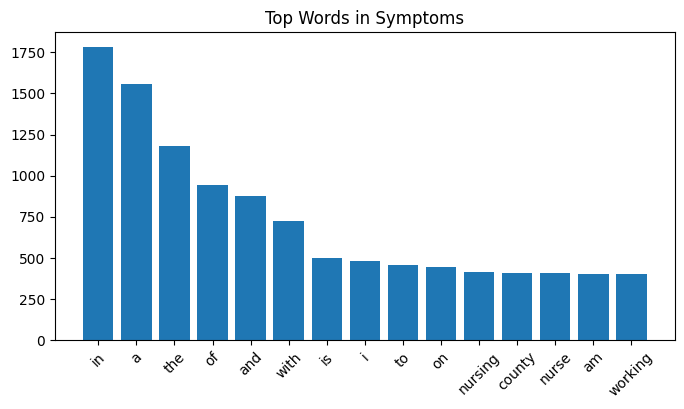

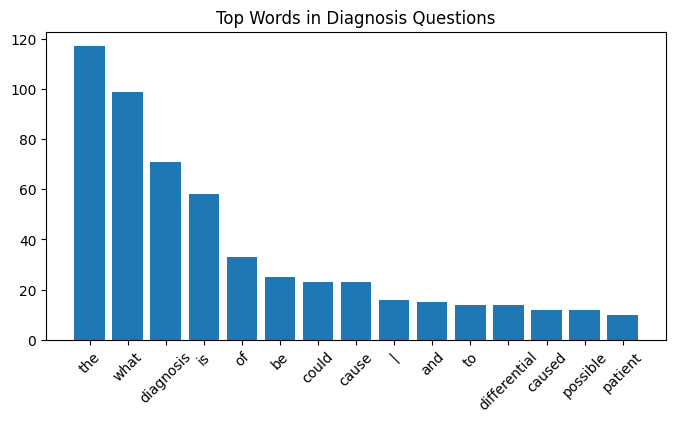

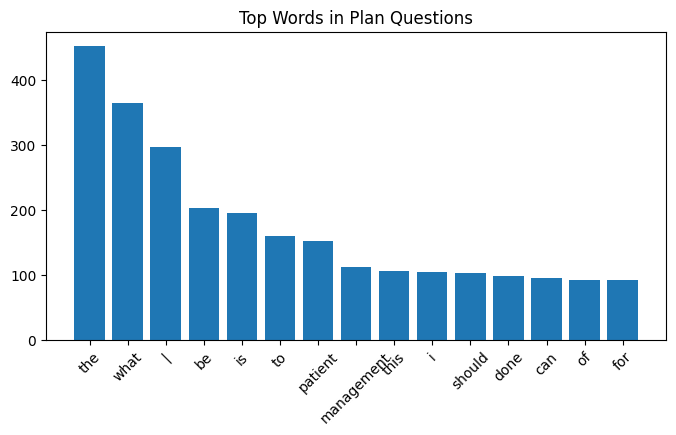

In [14]:
def plot_top_words(texts, title):
    words = " ".join([str(t) for t in texts]).lower().split()
    word_freq = Counter(words).most_common(15)
    words, counts = zip(*word_freq)
    plt.figure(figsize=(8,4))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.show()

plot_top_words(df["Symptoms"], "Top Words in Symptoms")
plot_top_words(df["Diagnosis_Qs"], "Top Words in Diagnosis Questions")
plot_top_words(df["Plan_Qs"], "Top Words in Plan Questions")


In [ ]:
output_path = "../data/train_clean.csv"
df.to_csv(output_path, index=False)

print("Cleaned dataset saved to:", output_path)
